# Analysis2ndSensor — Feature Engineering Pipeline
### New Sensor → Normalised Features → Merge-Ready Dataset

**Purpose:**  
Take raw calibration recordings from the 2nd tactile sensor  
(`Timestamp_ms`, `Weight_g`, `Resistance_kOhm`, `R_AbsOs_kOhm`)  
and produce a dataset with the same feature columns used by the CNN-LSTM pipeline:

| New column | Description |
|---|---|
| `force_n` | Weight converted to Newtons (÷ 1000 × 9.81) |
| `is_press` | Latching contact flag — mirrors runtime logic |
| `conductance` | `1 / (Resistance_kOhm + 1e-6)` |
| `shifted_cond` | Distribution-aligned conductance matching training baseline |

All logic mirrors **`ModelInclude.py`** exactly so merged data is drop-in compatible.


## Cell 1 — Imports

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

pd.set_option('display.float_format', '{:.6f}'.format)
plt.rcParams['figure.dpi'] = 110

DATA_DIR   = Path(r'Z:\Project\RoBoGrip\SensorCharaterize\Data')
OUTPUT_DIR = Path(r'Z:\Project\RoBoGrip\SensorCharaterize\Result')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"  Data dir   : {DATA_DIR}")
print(f"  Output dir : {OUTPUT_DIR}")


Imports OK
  Data dir   : Z:\Project\RoBoGrip\SensorCharaterize\Data
  Output dir : Z:\Project\RoBoGrip\SensorCharaterize\Result


## Cell 2 — Configuration
All constants that mirror `ModelInclude.py`. **Change only here.**

In [18]:
# ── Constants ─────────────────────────────────────────────────────────────────
TRAIN_BASELINE_G = 0.004369
PRESS_THRESHOLD  = 0.97
GRAVITY          = 9.81
RES_MAX_KOHM     = 800.0
REQUIRED_COLS    = ['Timestamp_ms', 'Weight_g', 'Resistance_kOhm', 'R_AbsOs_kOhm']

# ── Merge all CSV files → merge.csv ───────────────────────────────────────────
EXCLUDE_FILES = {'merge.csv'}
csv_files = sorted([f for f in DATA_DIR.glob('*.csv') if f.name not in EXCLUDE_FILES])

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

frames = []
for exp_id, path in enumerate(csv_files, start=1):
    chunk = pd.read_csv(path, header=None, usecols=[0, 1, 2, 3], names=REQUIRED_COLS)
    chunk = chunk.apply(pd.to_numeric, errors='coerce').dropna(how='any').reset_index(drop=True)
    chunk.insert(0, 'experiment_id', exp_id)
    chunk.insert(1, 'source_file', path.name)
    frames.append(chunk)
    print(f"  exp {exp_id:02d}  {path.name:<40}  {len(chunk):,} rows")

df = pd.concat(frames, ignore_index=True)

merge_path = OUTPUT_DIR / 'merge.csv'
df.to_csv(merge_path, index=False)

print(f"\nTotal : {len(df):,} rows  |  {df['experiment_id'].nunique()} experiments")
print(f"Saved : {merge_path}")


  exp 01  data_20260422_144313.csv                  118 rows
  exp 02  data_20260422_144424.csv                  44 rows
  exp 03  data_20260422_144452.csv                  110 rows
  exp 04  data_20260422_144557.csv                  27 rows
  exp 05  data_20260422_144724.csv                  85 rows
  exp 06  data_20260422_144823.csv                  270 rows

Total : 654 rows  |  6 experiments
Saved : Z:\Project\RoBoGrip\SensorCharaterize\Result\merge.csv


## Cell 3 — Load & Validate Raw Data

In [19]:
df = pd.read_csv(OUTPUT_DIR / 'merge.csv')

# Clamp negative weights to zero before any processing
neg_count = (df['Weight_g'] < 0).sum()
df['Weight_g'] = df['Weight_g'].clip(lower=0)
print(f"Clamped {neg_count:,} negative Weight_g values to 0")

print(f"Loaded merge.csv: {len(df):,} rows x {len(df.columns)} columns")
print(f"Experiments     : {df['experiment_id'].nunique()}")
print()
display(df[REQUIRED_COLS].describe().round(4))
print()
print("First 5 rows:")
display(df.head())


Clamped 85 negative Weight_g values to 0
Loaded merge.csv: 654 rows x 6 columns
Experiments     : 6



,Timestamp_ms,Weight_g,Resistance_kOhm,R_AbsOs_kOhm
count,654.000000,654.000000,654.000000,654.000000
mean,240004.227800,364.535600,43.222000,55.527200
std,145905.820400,403.569500,32.317700,30.866100
min,6019.000000,0.000000,5.830000,0.020000
25%,105524.250000,2.247500,16.342500,24.997500
50%,272016.500000,334.265000,26.050000,71.860000
75%,373727.750000,509.730000,73.410000,81.577500
max,463359.000000,2153.870000,164.970000,92.080000



First 5 rows:


,experiment_id,source_file,Timestamp_ms,Weight_g,Resistance_kOhm,R_AbsOs_kOhm
0,1,data_20260422_144313.csv,6019,0.380000,99.100000,1.180000
1,1,data_20260422_144313.csv,6568,0.310000,98.620000,0.700000
2,1,data_20260422_144313.csv,7117,0.340000,98.930000,1.010000
3,1,data_20260422_144313.csv,7666,0.340000,98.390000,0.470000
4,1,data_20260422_144313.csv,8215,0.320000,99.390000,1.480000


## Cell 4 — Sanitise Resistance
Clamp out-of-range values (open-circuit / sensor dropout) to `RES_MAX_KOHM`. Same guard used in `ModelInclude.py` Stage 4.

In [20]:
df = df.copy()

# Clamp Resistance_kOhm
bad_mask = (df['Resistance_kOhm'] <= 0) | (df['Resistance_kOhm'] > RES_MAX_KOHM)
n_bad = bad_mask.sum()
df.loc[bad_mask, 'Resistance_kOhm'] = RES_MAX_KOHM

# Clamp R_AbsOs_kOhm the same way (it is a per-row baseline snapshot)
bad_abs = (df['R_AbsOs_kOhm'] <= 0) | (df['R_AbsOs_kOhm'] > RES_MAX_KOHM)
n_bad_abs = bad_abs.sum()
df.loc[bad_abs, 'R_AbsOs_kOhm'] = RES_MAX_KOHM

print(f"Resistance_kOhm  — clamped {n_bad:,} rows  ({100*n_bad/len(df):.2f}%)")
print(f"R_AbsOs_kOhm     — clamped {n_bad_abs:,} rows  ({100*n_bad_abs/len(df):.2f}%)")
print()
print("After clamp stats:")
display(df[['Resistance_kOhm', 'R_AbsOs_kOhm']].describe().round(4))


Resistance_kOhm  — clamped 0 rows  (0.00%)
R_AbsOs_kOhm     — clamped 0 rows  (0.00%)

After clamp stats:


,Resistance_kOhm,R_AbsOs_kOhm
count,654.000000,654.000000
mean,43.222000,55.527200
std,32.317700,30.866100
min,5.830000,0.020000
25%,16.342500,24.997500
50%,26.050000,71.860000
75%,73.410000,81.577500
max,164.970000,92.080000


## Cell 5 — Force Conversion
`Weight_g` → `force_n`  
Formula: `force_n = Weight_g / 1000 × GRAVITY`  
Negative weights (scale rebound artefacts) are clipped to 0.

force_n stats:


count   654.000000
mean      3.576100
std       3.959000
min       0.000000
25%       0.022000
50%       3.279100
75%       5.000500
max      21.129500
Name: force_n, dtype: float64

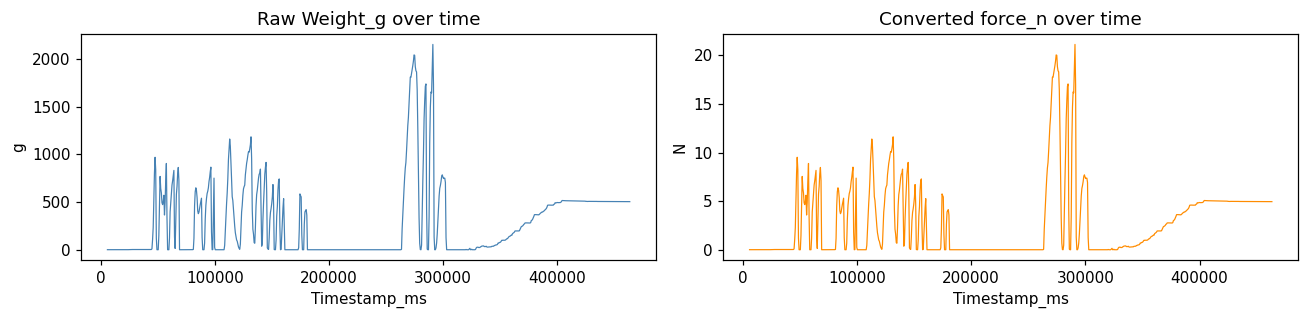

In [21]:
df['force_n'] = (df['Weight_g'].clip(lower=0) / 1000.0) * GRAVITY

print("force_n stats:")
display(df['force_n'].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(df['Timestamp_ms'], df['Weight_g'], lw=0.8, color='steelblue')
axes[0].set_title('Raw Weight_g over time')
axes[0].set_xlabel('Timestamp_ms')
axes[0].set_ylabel('g')

axes[1].plot(df['Timestamp_ms'], df['force_n'], lw=0.8, color='darkorange')
axes[1].set_title('Converted force_n over time')
axes[1].set_xlabel('Timestamp_ms')
axes[1].set_ylabel('N')

plt.tight_layout()
plt.show()


## Cell 6 — Conductance
Linearises the pressure response and suppresses open-circuit noise.  
Formula: `conductance = 1 / (Resistance_kOhm + 1e-6)`

conductance stats:


count   654.000000
mean      0.042393
std       0.032479
min       0.006062
25%       0.013622
50%       0.038388
75%       0.061190
max       0.171527
Name: conductance, dtype: float64

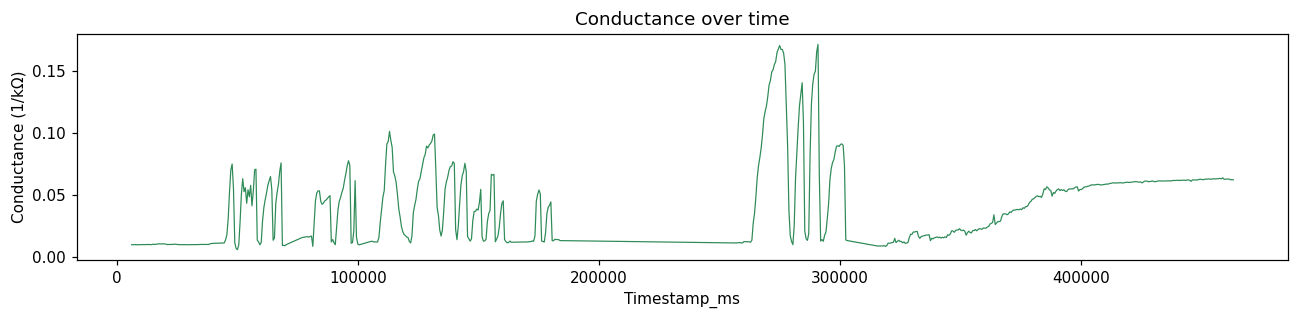

In [22]:
df['conductance'] = 1.0 / (df['Resistance_kOhm'] + 1e-6)

print("conductance stats:")
display(df['conductance'].describe().round(6))

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df['Timestamp_ms'], df['conductance'], lw=0.8, color='seagreen')
ax.set_title('Conductance over time')
ax.set_xlabel('Timestamp_ms')
ax.set_ylabel('Conductance (1/kΩ)')
plt.tight_layout()
plt.show()


## Cell 7 — `is_press` (Dynamic Contact Detection)
`R_AbsOs_kOhm` is the per-row no-contact baseline already captured by the new sensor.  
We apply the **same 97% threshold** used in `run_one_grip()` Stage 2:  
```
is_press = 1  when  Resistance_kOhm < R_AbsOs_kOhm × PRESS_THRESHOLD
```
**Latching:** once contact is detected within a trial, `is_press` stays 1 for the rest of that trial.  
If your CSV contains multiple trials, set `trial_id` column (see note below).

No 'trial_id' column — treating entire file as one trial (single latch).

is_press=1 rows: 581 / 654  (88.8%)



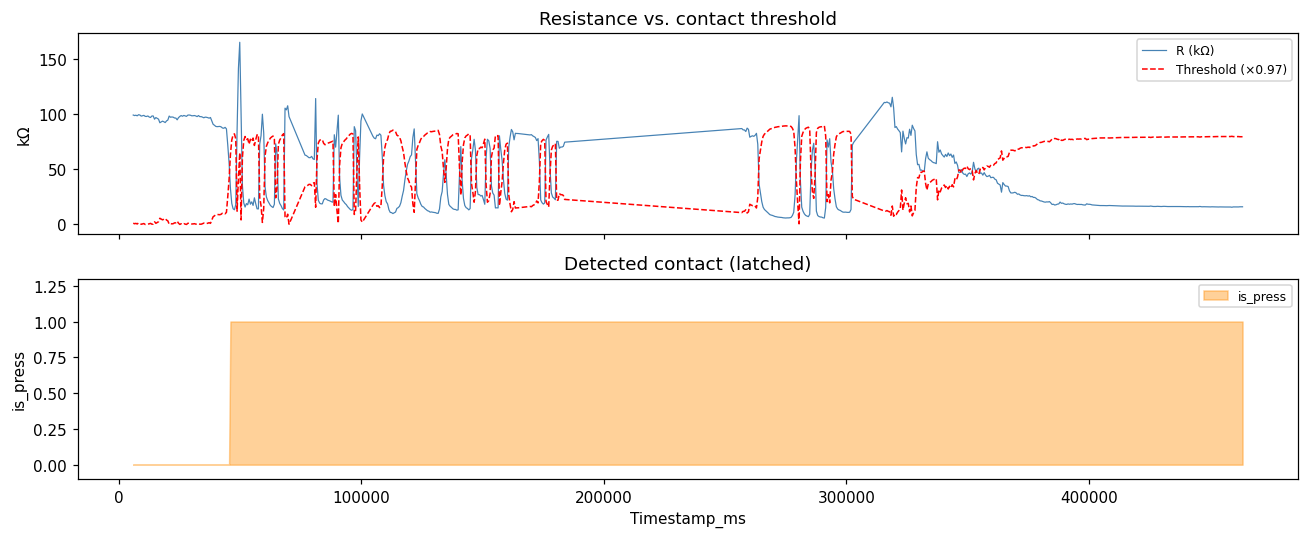

In [23]:
threshold_series = df['R_AbsOs_kOhm'] * PRESS_THRESHOLD
contact_raw = (df['Resistance_kOhm'] < threshold_series).astype(int)

# ── Latching logic ────────────────────────────────────────────────────────────
# If a 'trial_id' column exists, latch per trial.
# Otherwise treat the entire file as one continuous trial.

if 'trial_id' in df.columns:
    print("'trial_id' column found — latching is_press per trial.")
    df['is_press'] = (
        df.groupby('trial_id')['Resistance_kOhm']
        .transform(lambda r: (r < (df.loc[r.index, 'R_AbsOs_kOhm'] * PRESS_THRESHOLD))
                              .cummax().astype(int))
    )
else:
    print("No 'trial_id' column — treating entire file as one trial (single latch).")
    df['is_press'] = contact_raw.cummax().astype(int)

n_contact = df['is_press'].sum()
print(f"\nis_press=1 rows: {n_contact:,} / {len(df):,}  ({100*n_contact/len(df):.1f}%)")
print()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(df['Timestamp_ms'], df['Resistance_kOhm'], lw=0.8, label='R (kΩ)', color='steelblue')
axes[0].plot(df['Timestamp_ms'], threshold_series, lw=1, ls='--', label=f'Threshold (×{PRESS_THRESHOLD})', color='red')
axes[0].legend(fontsize=8)
axes[0].set_ylabel('kΩ')
axes[0].set_title('Resistance vs. contact threshold')

axes[1].fill_between(df['Timestamp_ms'], df['is_press'], alpha=0.4, color='darkorange', label='is_press')
axes[1].set_ylim(-0.1, 1.3)
axes[1].set_ylabel('is_press')
axes[1].set_xlabel('Timestamp_ms')
axes[1].set_title('Detected contact (latched)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Cell 8 — `shifted_cond` (Distribution Alignment)
The CNN-LSTM was trained on data where the idle conductance ≈ `TRAIN_BASELINE_G = 0.004369`.  
Each experiment has a different physical baseline. We compute a **per-experiment statistical baseline**  
by averaging the conductance of all `is_press = 0` rows within that experiment, then shift so  
the distribution aligns with the training distribution — **this is critical for correct inference.**

Formula:  
```
fixed_baseline_g = mean(conductance  where is_press == 0)  # per experiment
shifted_cond     = (conductance - fixed_baseline_g) + TRAIN_BASELINE_G
```


⚠️  experiment(s) [2, 3, 4, 5, 6] had no is_press=0 rows — used min conductance as baseline fallback.
NaN check — fixed_baseline_g: 0   shifted_cond: 0

Distribution alignment check:
  conductance    mean : 0.042393
  fixed_baseline mean : 0.009857  (per-experiment, is_press=0 rows)
  shifted_cond   mean : 0.036905  (target ≈ 0.004369)



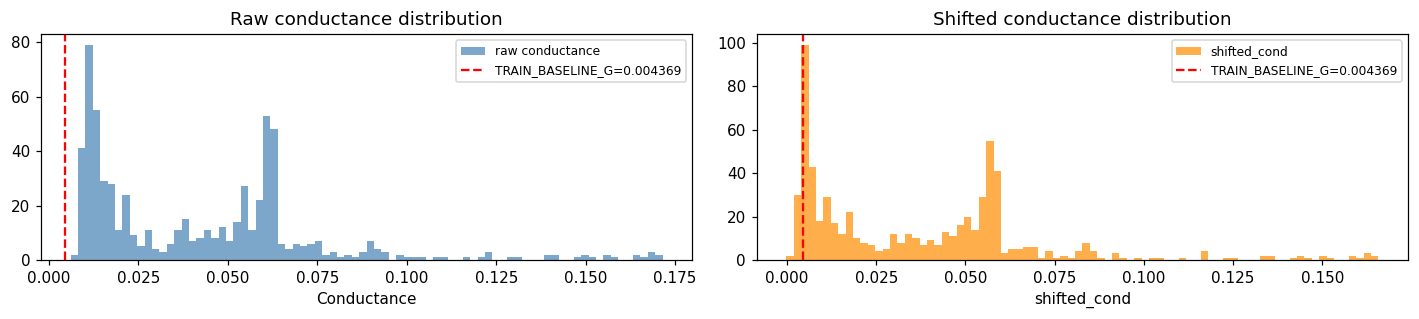

In [24]:
def prepare_sensor_data(df):
    baselines = (
        df[df['is_press'] == 0]
        .groupby('experiment_id')['conductance']
        .mean()
        .reset_index()
        .rename(columns={'conductance': 'fixed_baseline_g'})
    )
    df = df.merge(baselines, on='experiment_id', how='left')

    # Fallback: experiments with no is_press=0 rows → use min conductance (≈ no-contact state)
    missing = df['fixed_baseline_g'].isna()
    if missing.any():
        fallback = (
            df[missing].groupby('experiment_id')['conductance']
            .min()
            .rename('fixed_baseline_g')
        )
        df.loc[missing, 'fixed_baseline_g'] = df.loc[missing, 'experiment_id'].map(fallback)
        bad_exps = sorted(df.loc[missing, 'experiment_id'].unique().tolist())
        print(f'⚠️  experiment(s) {bad_exps} had no is_press=0 rows — used min conductance as baseline fallback.')

    df['shifted_cond'] = (df['conductance'] - df['fixed_baseline_g']) + TRAIN_BASELINE_G
    return df

df = prepare_sensor_data(df)

nan_sc = df['shifted_cond'].isna().sum()
nan_fb = df['fixed_baseline_g'].isna().sum()
print(f'NaN check — fixed_baseline_g: {nan_fb}   shifted_cond: {nan_sc}')
print()
print('Distribution alignment check:')
print(f"  conductance    mean : {df['conductance'].mean():.6f}")
print(f"  fixed_baseline mean : {df['fixed_baseline_g'].mean():.6f}  (per-experiment, is_press=0 rows)")
print(f"  shifted_cond   mean : {df['shifted_cond'].mean():.6f}  (target ≈ {TRAIN_BASELINE_G})")
print()

# ── Plot: before vs after shift ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3))

axes[0].hist(df['conductance'], bins=80, color='steelblue', alpha=0.7, label='raw conductance')
axes[0].axvline(TRAIN_BASELINE_G, color='red', ls='--', label=f'TRAIN_BASELINE_G={TRAIN_BASELINE_G}')
axes[0].set_title('Raw conductance distribution')
axes[0].set_xlabel('Conductance')
axes[0].legend(fontsize=8)

axes[1].hist(df['shifted_cond'], bins=80, color='darkorange', alpha=0.7, label='shifted_cond')
axes[1].axvline(TRAIN_BASELINE_G, color='red', ls='--', label=f'TRAIN_BASELINE_G={TRAIN_BASELINE_G}')
axes[1].set_title('Shifted conductance distribution')
axes[1].set_xlabel('shifted_cond')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Cell 9 — Resample to 1.8 Hz (CNN-LSTM Training Rate)
The CNN-LSTM was trained on data sampled at **1.8 Hz** (one sample every ≈556 ms).  
If this new sensor has a different native sample rate, resample **after** feature engineering  
(so that is_press latching and conductance shift are correct on the original timeline first).

Resampling uses **linear interpolation** for continuous features and  
**forward-fill** for the latching `is_press` flag.

In [25]:
TARGET_HZ   = 1.8
INTERVAL_MS = 1000.0 / TARGET_HZ   # ≈ 555.6 ms

# ── Native rate check ─────────────────────────────────────────────────────────
dt = df['Timestamp_ms'].diff().dropna()
native_median_ms = dt.median()
native_hz = 1000.0 / native_median_ms

print(f"Native sample rate  : {native_hz:.2f} Hz  (median Δt = {native_median_ms:.1f} ms)")
print(f"Target sample rate  : {TARGET_HZ} Hz  (Δt = {INTERVAL_MS:.1f} ms)")
print()

if abs(native_hz - TARGET_HZ) < 0.1:
    print("✅ Native rate already matches target — skipping resample.")
    df_resampled = df.copy()
else:
    print(f"Resampling {native_hz:.2f} Hz → {TARGET_HZ} Hz ...")

    t_start = df['Timestamp_ms'].iloc[0]
    t_end   = df['Timestamp_ms'].iloc[-1]
    t_new   = np.arange(t_start, t_end, INTERVAL_MS)

    # Continuous features — linear interpolation
    interp_cols = ['Resistance_kOhm', 'R_AbsOs_kOhm',
                   'force_n', 'conductance', 'fixed_baseline_g', 'shifted_cond']
    if 'Weight_g' in df.columns:
        interp_cols.insert(0, 'Weight_g')

    df_interp = pd.DataFrame({'Timestamp_ms': t_new})
    for col in interp_cols:
        df_interp[col] = np.interp(t_new, df['Timestamp_ms'], df[col])

    # is_press — forward fill (latching must be preserved)
    df_sorted = df[['Timestamp_ms', 'is_press']].sort_values('Timestamp_ms')
    df_interp['is_press'] = (
        df_sorted.set_index('Timestamp_ms')['is_press']
        .reindex(df_interp['Timestamp_ms'], method='ffill')
        .fillna(0)
        .astype(int)
        .values
    )

    # Optional passthrough columns
    for col in ['trial_id', 'material', 'tag']:
        if col in df.columns:
            df_interp[col] = (
                df.set_index('Timestamp_ms')[col]
                .reindex(df_interp['Timestamp_ms'], method='ffill')
                .values
            )

    df_resampled = df_interp
    print(f"  Original rows : {len(df):,}")
    print(f"  Resampled rows: {len(df_resampled):,}")

print()
display(df_resampled.describe().round(5))


Native sample rate  : 1.82 Hz  (median Δt = 549.0 ms)
Target sample rate  : 1.8 Hz  (Δt = 555.6 ms)

✅ Native rate already matches target — skipping resample.



,experiment_id,Timestamp_ms,Weight_g,Resistance_kOhm,R_AbsOs_kOhm,force_n,conductance,is_press,fixed_baseline_g,shifted_cond
count,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000
mean,4.111620,240004.227830,364.535600,43.222000,55.527160,3.576090,0.042390,0.888380,0.009860,0.036910
std,1.958550,145905.820430,403.569490,32.317680,30.866100,3.959020,0.032480,0.315140,0.001220,0.032590
min,1.000000,6019.000000,0.000000,5.830000,0.020000,0.000000,0.006060,0.000000,0.008680,-0.000180
25%,3.000000,105524.250000,2.247500,16.342500,24.997500,0.022050,0.013620,1.000000,0.008680,0.007500
50%,5.000000,272016.500000,334.265000,26.050000,71.860000,3.279140,0.038390,1.000000,0.010150,0.033280
75%,6.000000,373727.750000,509.730000,73.410000,81.577500,5.000450,0.061190,1.000000,0.010610,0.056600
max,6.000000,463359.000000,2153.870000,164.970000,92.080000,21.129460,0.171530,1.000000,0.012260,0.165750


## Cell 10 — Sanity Check: Original vs Resampled

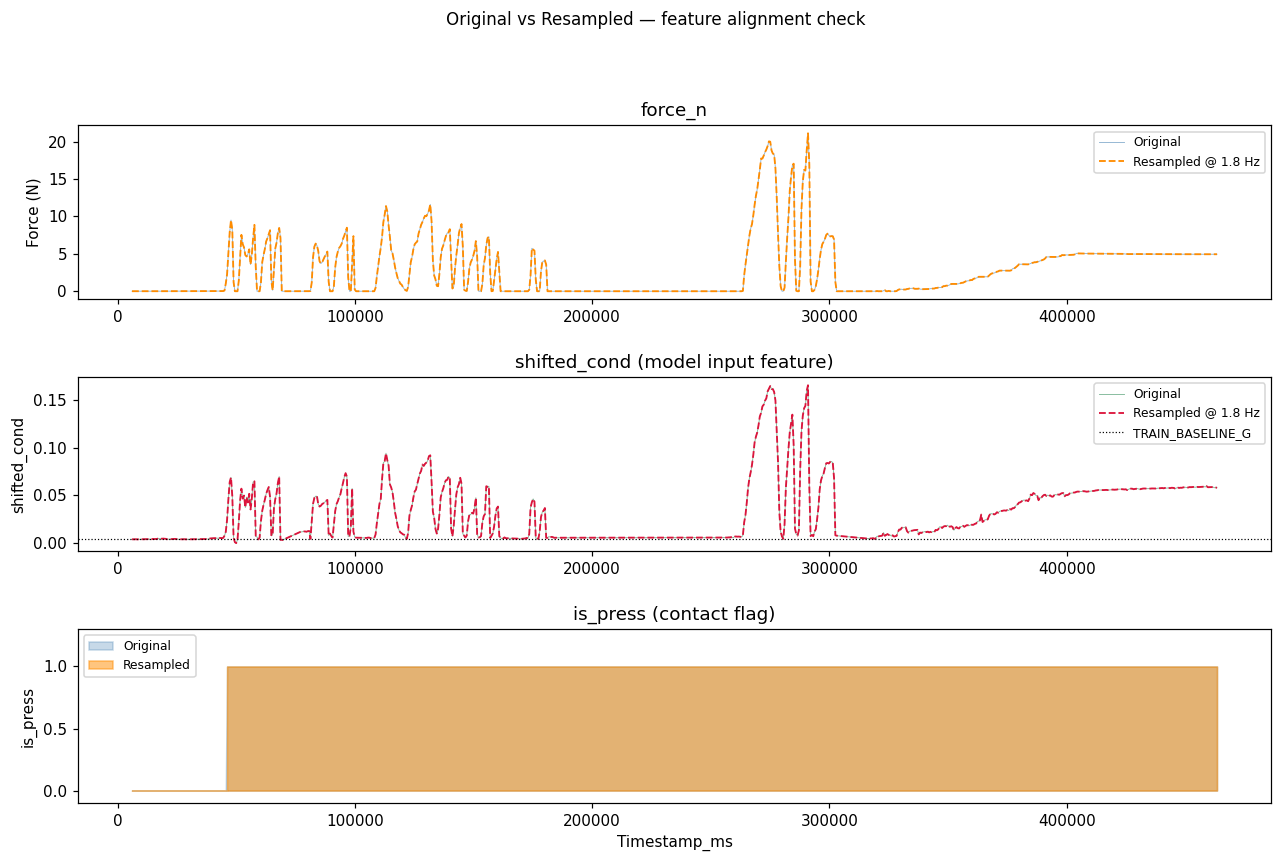

In [26]:
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# Force
ax0 = fig.add_subplot(gs[0])
ax0.plot(df['Timestamp_ms'], df['force_n'],
         lw=0.6, alpha=0.6, color='steelblue', label='Original')
ax0.plot(df_resampled['Timestamp_ms'], df_resampled['force_n'],
         lw=1.2, color='darkorange', label=f'Resampled @ {TARGET_HZ} Hz', ls='--')
ax0.set_ylabel('Force (N)')
ax0.set_title('force_n')
ax0.legend(fontsize=8)

# shifted_cond
ax1 = fig.add_subplot(gs[1])
ax1.plot(df['Timestamp_ms'], df['shifted_cond'],
         lw=0.6, alpha=0.6, color='seagreen', label='Original')
ax1.plot(df_resampled['Timestamp_ms'], df_resampled['shifted_cond'],
         lw=1.2, color='crimson', label=f'Resampled @ {TARGET_HZ} Hz', ls='--')
ax1.axhline(TRAIN_BASELINE_G, color='black', ls=':', lw=0.8, label='TRAIN_BASELINE_G')
ax1.set_ylabel('shifted_cond')
ax1.set_title('shifted_cond (model input feature)')
ax1.legend(fontsize=8)

# is_press
ax2 = fig.add_subplot(gs[2])
ax2.fill_between(df['Timestamp_ms'], df['is_press'],
                 alpha=0.3, color='steelblue', label='Original')
ax2.fill_between(df_resampled['Timestamp_ms'], df_resampled['is_press'],
                 alpha=0.5, color='darkorange', label=f'Resampled', step='post')
ax2.set_ylim(-0.1, 1.3)
ax2.set_ylabel('is_press')
ax2.set_xlabel('Timestamp_ms')
ax2.set_title('is_press (contact flag)')
ax2.legend(fontsize=8)

plt.suptitle('Original vs Resampled — feature alignment check', fontsize=11, y=1.01)
plt.show()


## Cell 11 — Feature Correlation Check
Verify that `shifted_cond` correlates with `force_n` after contact — this is the  
signal the CNN-LSTM depends on. Weak correlation may indicate sensor issues.

Correlation matrix (contact rows only):


,shifted_cond,conductance,force_n
shifted_cond,1.000000,0.999200,0.956600
conductance,0.999200,1.000000,0.960600
force_n,0.956600,0.960600,1.000000


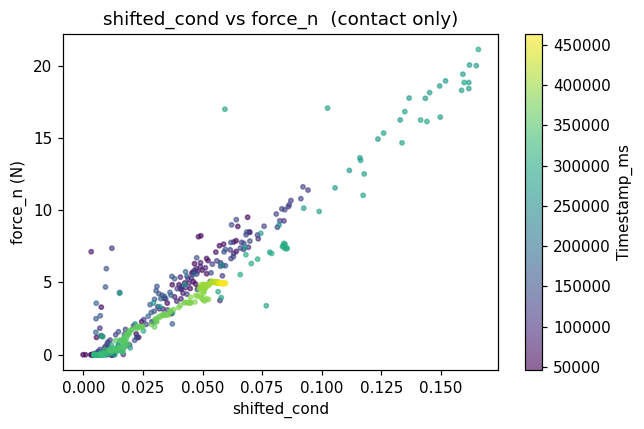

In [27]:
contact_df = df_resampled[df_resampled['is_press'] == 1]

if len(contact_df) < 5:
    print("⚠️  Too few contact samples for correlation check.")
else:
    corr = contact_df[['shifted_cond', 'conductance', 'force_n']].corr()
    print("Correlation matrix (contact rows only):")
    display(corr.round(4))

    fig, ax = plt.subplots(figsize=(6, 4))
    scatter = ax.scatter(
        contact_df['shifted_cond'], contact_df['force_n'],
        c=contact_df['Timestamp_ms'], cmap='viridis', s=8, alpha=0.6
    )
    plt.colorbar(scatter, ax=ax, label='Timestamp_ms')
    ax.set_xlabel('shifted_cond')
    ax.set_ylabel('force_n (N)')
    ax.set_title('shifted_cond vs force_n  (contact only)')
    plt.tight_layout()
    plt.show()


## Cell 12 — Build Final Merge-Ready DataFrame
Select and rename columns to match the existing dataset schema.  
Add `sensor_id = 'sensor_2'` so the two datasets remain distinguishable after merge.

In [28]:
FINAL_COLS = [
    'experiment_id',
    'Timestamp_ms',
    'force_n',
    'is_press',
    'conductance',
    'fixed_baseline_g',
    'shifted_cond',
    # passthrough originals for traceability
    'Resistance_kOhm',
    'R_AbsOs_kOhm',
]

# Add optional columns if present
for opt in ['Weight_g', 'trial_id', 'material', 'tag']:
    if opt in df_resampled.columns:
        FINAL_COLS.append(opt)

df_final = df_resampled[FINAL_COLS].copy()
df_final.insert(0, 'sensor_id', 'sensor_2')

# ── Final validation ──────────────────────────────────────────────────────────
assert df_final['shifted_cond'].isna().sum() == 0,  "NaN in shifted_cond!"
assert df_final['force_n'].isna().sum() == 0,       "NaN in force_n!"
assert df_final['is_press'].isin([0, 1]).all(),      "is_press has values other than 0/1!"
assert (df_final['force_n'] >= 0).all(),             "Negative force_n found!"

print(f"✅ Final DataFrame: {len(df_final):,} rows × {len(df_final.columns)} columns")
print()
print("Columns:")
for c in df_final.columns:
    print(f"  {c:<22} dtype={df_final[c].dtype}")
print()
display(df_final.head(8))


✅ Final DataFrame: 654 rows × 11 columns

Columns:
  sensor_id              dtype=object
  experiment_id          dtype=int64
  Timestamp_ms           dtype=int64
  force_n                dtype=float64
  is_press               dtype=int32
  conductance            dtype=float64
  fixed_baseline_g       dtype=float64
  shifted_cond           dtype=float64
  Resistance_kOhm        dtype=float64
  R_AbsOs_kOhm           dtype=float64
  Weight_g               dtype=float64



,sensor_id,experiment_id,Timestamp_ms,force_n,is_press,conductance,fixed_baseline_g,shifted_cond,Resistance_kOhm,R_AbsOs_kOhm,Weight_g
0,sensor_2,1,6019,0.003728,0,0.010091,0.010608,0.003852,99.100000,1.180000,0.380000
1,sensor_2,1,6568,0.003041,0,0.010140,0.010608,0.003901,98.620000,0.700000,0.310000
2,sensor_2,1,7117,0.003335,0,0.010108,0.010608,0.003869,98.930000,1.010000,0.340000
3,sensor_2,1,7666,0.003335,0,0.010164,0.010608,0.003924,98.390000,0.470000,0.340000
4,sensor_2,1,8215,0.003139,0,0.010061,0.010608,0.003822,99.390000,1.480000,0.320000
5,sensor_2,1,8764,0.003630,0,0.010091,0.010608,0.003852,99.100000,1.180000,0.370000
6,sensor_2,1,9312,0.003434,0,0.010193,0.010608,0.003953,98.110000,0.200000,0.350000
7,sensor_2,1,9861,0.003924,0,0.010162,0.010608,0.003922,98.410000,0.490000,0.400000


## Cell 13 — Save Outputs

In [29]:
out_features = OUTPUT_DIR / 'sensor2_features.csv'
df_final.to_csv(out_features, index=False)
print(f"Features saved   : {out_features}  ({len(df_final):,} rows)")

out_full = OUTPUT_DIR / 'sensor2_full_pipeline.csv'
df_resampled.to_csv(out_full, index=False)
print(f"Full pipeline    : {out_full}  ({len(df_resampled):,} rows)")

print()
print("Column summary of saved features file:")
display(df_final.describe().round(5))


Features saved   : Z:\Project\RoBoGrip\SensorCharaterize\Result\sensor2_features.csv  (654 rows)
Full pipeline    : Z:\Project\RoBoGrip\SensorCharaterize\Result\sensor2_full_pipeline.csv  (654 rows)

Column summary of saved features file:


,experiment_id,Timestamp_ms,force_n,is_press,conductance,fixed_baseline_g,shifted_cond,Resistance_kOhm,R_AbsOs_kOhm,Weight_g
count,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000
mean,4.111620,240004.227830,3.576090,0.888380,0.042390,0.009860,0.036910,43.222000,55.527160,364.535600
std,1.958550,145905.820430,3.959020,0.315140,0.032480,0.001220,0.032590,32.317680,30.866100,403.569490
min,1.000000,6019.000000,0.000000,0.000000,0.006060,0.008680,-0.000180,5.830000,0.020000,0.000000
25%,3.000000,105524.250000,0.022050,1.000000,0.013620,0.008680,0.007500,16.342500,24.997500,2.247500
50%,5.000000,272016.500000,3.279140,1.000000,0.038390,0.010150,0.033280,26.050000,71.860000,334.265000
75%,6.000000,373727.750000,5.000450,1.000000,0.061190,0.010610,0.056600,73.410000,81.577500,509.730000
max,6.000000,463359.000000,21.129460,1.000000,0.171530,0.012260,0.165750,164.970000,92.080000,2153.870000


## Cell 14 — Merge with Existing Dataset (Template)
Uncomment and set `EXISTING_CSV` to the path of your original sensor-1 dataset.  
Both datasets must have the same schema columns produced by this notebook.

In [30]:
# EXISTING_CSV = './data/sensor1_features.csv'   # ← uncomment and set path

# df_existing = pd.read_csv(EXISTING_CSV)
# df_existing.insert(0, 'sensor_id', 'sensor_1')

# df_merged = pd.concat([df_existing, df_final], ignore_index=True)
# df_merged = df_merged.sort_values(['trial_id', 'Timestamp_ms']).reset_index(drop=True) \
#             if 'trial_id' in df_merged.columns else \
#             df_merged.sort_values('Timestamp_ms').reset_index(drop=True)

# out_merged = DATA_DIR / 'merged_both_sensors.csv'
# df_merged.to_csv(out_merged, index=False)
# print(f"✅ Merged dataset: {out_merged}  ({len(df_merged):,} rows)")
# display(df_merged.groupby('sensor_id').describe()['shifted_cond'].round(5))

print("Cell 14 is a template — set EXISTING_CSV path and uncomment to run.")


Cell 14 is a template — set EXISTING_CSV path and uncomment to run.


## Cell 15 — Merge All CSV Files & Assign Experiment ID
Scans `./data/` for every `*.csv`, concatenates them, and assigns a unique
`experiment_id` per source file so rows stay traceable after merging.
Saves the result to `./data/merged_all_experiments.csv`.

In [32]:
import pandas as pd
from pathlib import Path

# Scans OUTPUT_DIR for processed *_features.csv files produced by Cell 13.
EXCLUDE = {'merged_all_experiments.csv'}
feat_files = sorted([
    f for f in OUTPUT_DIR.glob('*_features.csv')
    if f.name not in EXCLUDE
])

if not feat_files:
    raise FileNotFoundError(f'No *_features.csv files found in {OUTPUT_DIR}. Run Cell 13 first.')

print(f'Found {len(feat_files)} feature file(s):')
for f in feat_files:
    print(f'  {f.name}')
print()

frames = []
for path_f in feat_files:
    df_exp = pd.read_csv(path_f)
    df_exp.insert(0, 'experiment_src', path_f.name)
    frames.append(df_exp)
    print(f'  {path_f.name:<50}  {len(df_exp):>6,} rows')

df_merged = pd.concat(frames, ignore_index=True)

sort_cols = ['experiment_id'] if 'experiment_id' in df_merged.columns else []
if 'Timestamp_ms' in df_merged.columns:
    sort_cols.append('Timestamp_ms')
if sort_cols:
    df_merged = df_merged.sort_values(sort_cols).reset_index(drop=True)

print()
print(f'Merged shape : {df_merged.shape}')
print(f'Columns      : {list(df_merged.columns)}')
print()
print('Rows per experiment:')
group_cols = ['experiment_id', 'experiment_src'] if 'experiment_id' in df_merged.columns else ['experiment_src']
display(df_merged.groupby(group_cols).size()
        .rename('n_rows').reset_index())

out_path = OUTPUT_DIR / 'merged_all_experiments.csv'
df_merged.to_csv(out_path, index=False)
print(f'Saved: {out_path}  ({len(df_merged):,} rows total)')


Found 1 feature file(s):
  sensor2_features.csv

  sensor2_features.csv                                   654 rows

Merged shape : (654, 12)
Columns      : ['experiment_src', 'sensor_id', 'experiment_id', 'Timestamp_ms', 'force_n', 'is_press', 'conductance', 'fixed_baseline_g', 'shifted_cond', 'Resistance_kOhm', 'R_AbsOs_kOhm', 'Weight_g']

Rows per experiment:


,experiment_id,experiment_src,n_rows
0,1,sensor2_features.csv,118
1,2,sensor2_features.csv,44
2,3,sensor2_features.csv,110
3,4,sensor2_features.csv,27
4,5,sensor2_features.csv,85
5,6,sensor2_features.csv,270


Saved: Z:\Project\RoBoGrip\SensorCharaterize\Result\merged_all_experiments.csv  (654 rows total)


In [2]:
import pandas as pd
import numpy as np
import os

# --- 1. ตั้งค่าพื้นฐาน ---
CSV_PATH = r"Z:\Project\RoBoGrip\SensorCharaterize\Result\merged_all_experiments.csv"
XLSX_PATH = r"Z:\Project\RoBoGrip\Data\TrainExp_Processed.xlsx"
OUTPUT_PATH = r"Z:\Project\RoBoGrip\SensorCharaterize\Result\Final_Combined_Dataset.csv"

TRAIN_BASELINE_G = 0.004369  # ค่าอ้างอิงจากชุดเทรนเดิม
NEW_SENSOR_GAIN = 0.08       # Gain สำหรับเซนเซอร์ตัวใหม่

def load_and_normalize(path, is_excel=False):
    # โหลดไฟล์
    df = pd.read_excel(path) if is_excel else pd.read_csv(path)
    # ปรับชื่อคอลัมน์เป็นตัวพิมพ์เล็กทั้งหมดเพื่อป้องกันปัญหา Case-sensitivity
    df.columns = df.columns.str.lower()
    return df

print("กำลังโหลดไฟล์...")
df_new = load_and_normalize(CSV_PATH)   # ข้อมูลเซนเซอร์ใหม่
df_old = load_and_normalize(XLSX_PATH, is_excel=True) # ข้อมูลชุดเทรนเดิม

# --- 2. จัดการ Feature Engineering สำหรับเซนเซอร์ใหม่ (CSV) ---
print("กำลังปรับจูนสเกลเซนเซอร์ใหม่ (Gain 0.08)...")

# ตรวจสอบชื่อคอลัมน์ที่จำเป็น
# ในไฟล์ CSV เดิมของคุณมี 'resistance_kohm' หรือ 'conductance'
if 'conductance' not in df_new.columns:
    df_new['conductance'] = 1.0 / (df_new['resistance_kohm'] + 1e-6)

# หา Fixed Baseline ของแต่ละ experiment_id ในฝั่งเซนเซอร์ใหม่
# ล็อคค่า baseline ให้นิ่งเฉพาะช่วงที่ยังไม่มีการบีบ (is_press == 0)
baselines = df_new[df_new['is_press'] == 0].groupby('experiment_id')['conductance'].mean().reset_index()
baselines.rename(columns={'conductance': 'fixed_baseline_g'}, inplace=True)
df_new = df_new.merge(baselines, on='experiment_id', how='left')

# ทำ Shifting และ Scaling ตามสูตรที่วิเคราะห์ไว้
# G_shifted = ((G_raw - G_baseline) * 0.08) + 0.004369
df_new['conductance_processed'] = ((df_new['conductance'] - df_new['fixed_baseline_g']) * NEW_SENSOR_GAIN) + TRAIN_BASELINE_G

# --- 3. เตรียมข้อมูลเพื่อรวม (Column Selection) ---
# เลือกเฉพาะคอลัมน์ที่ต้องการ: is_press, conductance, force_n
cols_to_keep = ['is_press', 'force_n']

# สำหรับฝั่งใหม่ ใช้ค่าที่ผ่านการ Process แล้วแทนค่าเดิม
df_new_final = df_new[cols_to_keep + ['conductance_processed']].copy()
df_new_final.rename(columns={'conductance_processed': 'conductance'}, inplace=True)
df_new_final['source'] = 'new_sensor'

# สำหรับฝั่งเก่า ใช้ค่าเดิม (เพราะ Gain เป็น 1.0 อยู่แล้ว)
df_old_final = df_old[cols_to_keep + ['conductance']].copy()
df_old_final['source'] = 'old_sensor'

# --- 4. รวมไฟล์และรัน ID ใหม่ ---
print("กำลังรวมไฟล์และรัน ID ใหม่...")
combined_df = pd.concat([df_old_final, df_new_final], ignore_index=True)

# สร้าง Unique ID ใหม่โดยรวมจาก Source และ ID เดิม เพื่อให้แยกแยะได้ง่ายในอนาคต
# วิธีนี้จะทำให้ ID เริ่มรันใหม่ 1, 2, 3... ตามลำดับการวางไฟล์
combined_df['new_experiment_id'] = combined_df.groupby(['source', combined_df.index // 1000]).ngroup() + 1 

# --- 5. บันทึกผล ---
combined_df.to_csv(OUTPUT_PATH, index=False)
print(f"เสร็จเรียบร้อย! ไฟล์ถูกบันทึกไว้ที่: {OUTPUT_PATH}")
print(f"จำนวนข้อมูลทั้งหมด: {len(combined_df)} แถว")

กำลังโหลดไฟล์...


ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.